In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dipy.data import fetch_tissue_data, read_tissue_data
from dipy.segment.tissue import TissueClassifierHMRF

from dipy.io.image import load_nifti

In [2]:
# get image
data, affine, img = load_nifti("E:\\Documents\\DipySegmentation\\N4_Test.nii", return_img = True)
print(data.shape)
orig = img.get_fdata()

(256, 256, 160)


In [3]:
nclass = 3
beta = 0.1

In [4]:
import os

workspace_location = os.getcwd()

print(workspace_location)


e:\Documents\DipySegmentation


In [6]:
import time
t0 = time.time()

hmrf = TissueClassifierHMRF()
initial_segmentation, final_segmentation, PVE = hmrf.classify(orig, nclass, beta)

t1 = time.time()

total_time = t1-t0
print('Total time:' + str(total_time))


>> Iteration: 0
>> Iteration: 1
>> Iteration: 2
>> Iteration: 3
>> Iteration: 4
>> Iteration: 5
>> Iteration: 6
>> Iteration: 7
>> Iteration: 8
>> Iteration: 9
>> Iteration: 10
>> Iteration: 11
>> Iteration: 12
>> Iteration: 13


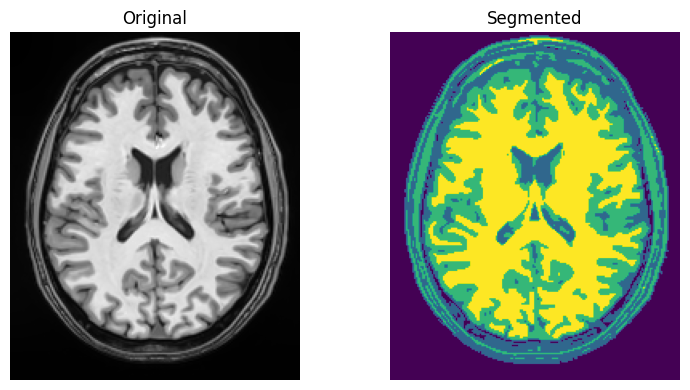

In [8]:

# Calculate axial middle
axial_middle = data.shape[2] // 2

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(8, 4) 

# First subplot - data[:, :, axial_middle]
axes[0].set_axis_off()
axes[0].imshow(data[:, :, axial_middle].T, cmap='gray', origin='lower')
axes[0].set_title('Original')

# Second subplot - final_segmentation[..., 89]
axes[1].set_axis_off()
axes[1].imshow(np.rot90(final_segmentation[..., 89]))
axes[1].set_title('Segmented')

# Adjust the spacing between subplots
plt.tight_layout()

# Save the figure
plt.savefig('final_seg.png', bbox_inches='tight', pad_inches=0)

In [ ]:
fig = plt.figure(figsize=(12, 6))

plt.suptitle("Predicted Labels")
plt.subplots_adjust(top=1, wspace=0.1)


a = fig.add_subplot(1, 4, 1)
# Add your code to load and display the additional image here
img_additional_slice = np.rot90(data[:, :, 89])
imgplot = plt.imshow(img_additional_slice, cmap="gray")
a.axis('off')
a.set_title('Original')

a = fig.add_subplot(1, 4, 2)
img_ax = np.rot90(PVE[..., 89, 0])
imgplot = plt.imshow(img_ax, cmap="gray")
a.axis('off')
a.set_title('CSF')

a = fig.add_subplot(1, 4, 3)
img_cor = np.rot90(PVE[:, :, 89, 1])
imgplot = plt.imshow(img_cor, cmap="gray")
a.axis('off')
a.set_title('Gray Matter')

a = fig.add_subplot(1, 4, 4)
img_cor = np.rot90(PVE[:, :, 89, 2])
imgplot = plt.imshow(img_cor, cmap="gray")
a.axis('off')
a.set_title('White Matter')


plt.savefig('probabilities.png', bbox_inches='tight', pad_inches=0)
plt.show()




